### GigaPath-Style WSI Preprocessing (streaming)

Workflow:
1. Foreground segmentation (`get_luminance`, `segment_foreground`) on thumbnail.
2. Grid coordinate generation at level-0.
3. Occupancy filtering using thumbnail mask.
4. Optional random max-tile cap.
5. Streaming tile extraction (read one tile at a time from WSI).
6. Save tile images + `dataset.csv`.


In [1]:
import torch 
print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
NVIDIA A30


In [2]:
!hostname
!which python
!echo $CUDA_VISIBLE_DEVICES
!nvidia-smi

hpctpa3pc0001


/share/lab_teng/trainee/tusharsingh/cell-seg/.pixi/envs/default/bin/python
0
Wed Mar 11 22:33:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A30                     On  |   00000000:21:00.0 Off |                    0 |
| N/A   28C    P0             29W /  165W |       4MiB /  24576MiB |      0%      Default |
|                                         |                    

## 2) Imports and paths


In [3]:
import csv
import logging
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
from PIL import Image
from IPython.display import display
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import skimage.filters
from openslide import OpenSlide
import monai

SLIDE_DIR = Path('/share/lab_teng/trainee/tusharsingh/cell-seg/data/wsi/')
OUT_DIR = Path('/share/lab_teng/trainee/tusharsingh/cell-seg/data/patches')
THUMBNAIL_DIR = OUT_DIR / 'thumbnails'
MANIFEST_CSV = Path('/share/lab_teng/trainee/tusharsingh/cell-seg/data/wsi/slide_manifest.csv')

OUT_DIR.mkdir(parents=True, exist_ok=True)
THUMBNAIL_DIR.mkdir(parents=True, exist_ok=True)

logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')
print('MONAI version:', monai.__version__)


MONAI version: 1.4.0


In [4]:
import os

# Safe starting point for a 64-core node. Increase after profiling storage throughput.
os.environ['OMP_NUM_THREADS'] = '12'
os.environ['MKL_NUM_THREADS'] = '12'
os.environ['OPENBLAS_NUM_THREADS'] = '12'
os.environ['NUMEXPR_NUM_THREADS'] = '12'

# Suggested runtime knobs
HPC_CPU_WORKERS_START = 12   # start around 24, then test 32, 40
HPC_CPU_WORKERS_MAX = 16     # usually avoid full 64 to reduce I/O contention
A30_INFER_BATCH_START = 32  # for downstream feature inference

print('HPC presets loaded')
print('HPC_CPU_WORKERS_START =', HPC_CPU_WORKERS_START)
print('A30_INFER_BATCH_START =', A30_INFER_BATCH_START)


HPC presets loaded
HPC_CPU_WORKERS_START = 12
A30_INFER_BATCH_START = 32


#### 3) Config


In [5]:
@dataclass
class StreamingConfig:
    # Physical extraction controls
    target_mpp: float = 0.5
    tile_size: int = 256
    overlap: int = 0

    # Foreground/tissue filtering
    thumbnail_max_size: int = 1024
    foreground_threshold: Optional[float] = None
    occupancy_threshold: float = 0.5

    # Optional cap after occupancy filtering
    max_tiles_per_slide: Optional[int] = 10
    random_seed: Optional[int] = 42

    # Metadata fallback
    fallback_mpp: float = 0.25

    # Outputs
    image_format: str = 'png'
    save_thumbnails: bool = True

CFG = StreamingConfig()
CFG


StreamingConfig(target_mpp=0.5, tile_size=256, overlap=0, thumbnail_max_size=1024, foreground_threshold=None, occupancy_threshold=0.5, max_tiles_per_slide=10, random_seed=42, fallback_mpp=0.25, image_format='png', save_thumbnails=True)

#### 4) Foreground segmentation functions


In [6]:
def get_luminance(slide: np.ndarray) -> np.ndarray:
    """Compute luminance from RGB array in (*, C, H, W).

    Input shape:  (*, 3, H, W)
    Output shape: (*, H, W)
    """
    return slide.mean(axis=-3, dtype=np.float16)


def segment_foreground(slide: np.ndarray, threshold: Optional[float] = None) -> Tuple[np.ndarray, float]:
    """Segment foreground by thresholding luminance.

    Foreground definition: luminance < threshold.
    """
    luminance = get_luminance(slide)
    if threshold is None:
        # Otsu can fail on nearly constant images; fallback to median.
        try:
            threshold = float(skimage.filters.threshold_otsu(luminance))
        except Exception:
            threshold = float(np.median(luminance))
    logging.info(f'Otsu threshold from luminance: {threshold}')
    return luminance < threshold, threshold


#### 5) Slide metadata + thumbnail mask


In [8]:
def get_slide_mpp(slide: OpenSlide, fallback_mpp: float = 0.25) -> float:
    """Read native MPP from slide metadata."""
    props = slide.properties
    for key in ('openslide.mpp-x', 'aperio.MPP'):
        if key in props:
            try:
                val = float(props[key])
                if val > 0:
                    return val
            except Exception:
                pass
    return fallback_mpp


def make_tissue_mask(
    slide: OpenSlide,
    thumbnail_max_size: int,
    threshold: Optional[float] = None,
    morph_ksize: int = 5,
) -> Tuple[np.ndarray, float, Tuple[int, int], float]:
    """Build binary tissue mask on thumbnail.

    Returns:
        mask: (H_thumb, W_thumb) uint8 in {0,1}
        thumb_downsample: level0_px / thumb_px
        thumb_size: (W_thumb, H_thumb)
        used_threshold: Otsu or provided threshold
    """
    w0, h0 = slide.dimensions
    scale = min(thumbnail_max_size / max(w0, h0), 1.0)
    tw, th = max(1, int(w0 * scale)), max(1, int(h0 * scale))

    thumb_rgb = slide.get_thumbnail((tw, th)).convert('RGB')
    thumb_hwc = np.array(thumb_rgb)
    thumb_chw = np.transpose(thumb_hwc, (2, 0, 1))

    fg_mask, used_threshold = segment_foreground(thumb_chw, threshold=threshold)
    mask = fg_mask.astype(np.uint8)

    if morph_ksize > 1:
        import cv2
        kernel = np.ones((morph_ksize, morph_ksize), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
        mask = (mask > 0).astype(np.uint8)

    thumb_downsample = w0 / tw
    return mask, thumb_downsample, (tw, th), used_threshold


#### 6) Grid generation + occupancy filter 


In [9]:
def compute_scale(native_mpp: float, target_mpp: float) -> float:
    """Scale from target pixels to level-0 pixels."""
    if native_mpp <= 0 or target_mpp <= 0:
        raise ValueError('native_mpp and target_mpp must be > 0')
    return target_mpp / native_mpp


def generate_tile_grid(slide_dims: Tuple[int, int], tile_size_level0: int, stride_level0: int) -> np.ndarray:
    """Generate candidate tile coordinates (x, y) in level-0 pixels."""
    if tile_size_level0 <= 0 or stride_level0 <= 0:
        raise ValueError('tile_size_level0 and stride_level0 must be > 0')

    w, h = slide_dims
    xs = np.arange(0, max(1, w - tile_size_level0 + 1), stride_level0, dtype=np.int64)
    ys = np.arange(0, max(1, h - tile_size_level0 + 1), stride_level0, dtype=np.int64)
    mesh = np.stack(np.meshgrid(xs, ys), axis=-1)
    return mesh.reshape(-1, 2)


def occupancy_for_tile(coord_xy: Sequence[int], tile_size_level0: int, tissue_mask: np.ndarray, thumb_downsample: float) -> float:
    """Compute tissue occupancy for one level-0 tile using thumbnail mask."""
    x0, y0 = int(coord_xy[0]), int(coord_xy[1])
    mx0 = int(x0 / thumb_downsample)
    my0 = int(y0 / thumb_downsample)
    mx1 = int((x0 + tile_size_level0) / thumb_downsample)
    my1 = int((y0 + tile_size_level0) / thumb_downsample)

    h, w = tissue_mask.shape
    mx0, my0 = max(0, mx0), max(0, my0)
    mx1, my1 = min(w, mx1), min(h, my1)
    if mx1 <= mx0 or my1 <= my0:
        return 0.0

    return float(tissue_mask[my0:my1, mx0:mx1].mean())


def filter_coords_by_occupancy(
    coords_xy: np.ndarray,
    tile_size_level0: int,
    tissue_mask: np.ndarray,
    thumb_downsample: float,
    occupancy_threshold: float,
) -> Tuple[np.ndarray, np.ndarray]:
    """Keep coords where occupancy > threshold.

    Returns:
        kept_coords: (N_kept, 2)
        kept_occupancies: (N_kept,)
    """
    if occupancy_threshold < 0.0 or occupancy_threshold > 1.0:
        raise ValueError('occupancy_threshold must be between 0 and 1')

    occs = np.array([
        occupancy_for_tile(c, tile_size_level0, tissue_mask, thumb_downsample)
        for c in coords_xy
    ], dtype=np.float32)

    selected = occs > occupancy_threshold
    return coords_xy[selected], occs[selected]


def random_sample_coords(
    coords_xy: np.ndarray,
    occupancies: np.ndarray,
    max_tiles: Optional[int],
    random_seed: Optional[int],
) -> Tuple[np.ndarray, np.ndarray]:
    """Randomly sample coords without replacement after occupancy filtering."""
    n = len(coords_xy)
    if max_tiles is None or max_tiles >= n:
        return coords_xy, occupancies
    if max_tiles <= 0:
        return coords_xy[:0], occupancies[:0]

    rng = np.random.default_rng(random_seed)
    idx = np.sort(rng.choice(n, size=max_tiles, replace=False))
    return coords_xy[idx], occupancies[idx]


#### 7) Streaming tile extraction helpers


In [10]:
def read_tile_at_target_mpp(
    slide: OpenSlide,
    coord_xy: Sequence[int],
    tile_size_target: int,
    native_mpp: float,
    target_mpp: float,
) -> np.ndarray:
    """Read one tile from WSI and return CHW uint8.

    Output shape: (3, tile_size_target, tile_size_target)
    """
    x0, y0 = int(coord_xy[0]), int(coord_xy[1])
    scale = compute_scale(native_mpp, target_mpp)
    read_size = max(1, int(round(tile_size_target * scale)))

    tile = slide.read_region((x0, y0), 0, (read_size, read_size)).convert('RGB')
    if read_size != tile_size_target:
        tile = tile.resize((tile_size_target, tile_size_target), Image.BILINEAR)

    tile_hwc = np.array(tile, dtype=np.uint8)
    return np.moveaxis(tile_hwc, -1, 0)


def get_tile_descriptor(tile_location: Sequence[int]) -> str:
    return f"{int(tile_location[0]):05d}x_{int(tile_location[1]):05d}y"


def get_tile_id(slide_id: str, tile_location: Sequence[int]) -> str:
    return f"{slide_id}.{get_tile_descriptor(tile_location)}"


def save_image(tile_chw: np.ndarray, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    tile_hwc = np.moveaxis(tile_chw, 0, -1)
    Image.fromarray(tile_hwc).save(path)


def get_tile_info(
    sample: Dict[str, Any],
    occupancy: float,
    tile_location: Sequence[int],
    rel_slide_dir: Path,
    image_format: str = 'png',
) -> Dict[str, Any]:
    slide_id = sample['slide_id']
    descriptor = get_tile_descriptor(tile_location)
    ext = image_format.lower().lstrip('.')
    return {
        'slide_id': slide_id,
        'tile_id': get_tile_id(slide_id, tile_location),
        'image': f"{rel_slide_dir}/{descriptor}.{ext}",
        'label': sample.get('label', None),
        'tile_x': int(tile_location[0]),
        'tile_y': int(tile_location[1]),
        'occupancy': float(occupancy),
        'metadata': {'slide_' + k: v for k, v in sample.get('metadata', {}).items()},
    }


#### 8) End-to-end per-slide processing (streaming)

Difference from full-ROI notebook: this function never builds all tile images in RAM.


In [11]:
def save_thumbnail(slide_path: Path, output_path: Path, size_target: int = 1024) -> None:
    with OpenSlide(str(slide_path)) as s:
        scale = size_target / max(s.dimensions)
        thumbnail = s.get_thumbnail([int(m * scale) for m in s.dimensions])
        output_path.parent.mkdir(parents=True, exist_ok=True)
        thumbnail.save(output_path)


def process_slide_streaming(sample: Dict[str, Any], cfg: StreamingConfig, output_dir: Path, thumbnail_dir: Path) -> Path:
    """Process one slide using coordinate filtering + streaming tile reads."""
    if cfg.tile_size <= 0:
        raise ValueError('cfg.tile_size must be > 0')
    if cfg.overlap < 0:
        raise ValueError('cfg.overlap must be >= 0')
    if cfg.overlap >= cfg.tile_size:
        raise ValueError('cfg.overlap must be smaller than cfg.tile_size')
    if cfg.thumbnail_max_size <= 0:
        raise ValueError('cfg.thumbnail_max_size must be > 0')

    slide_id = sample['slide_id']
    slide_path = Path(sample['image'])

    rel_slide_dir = Path(slide_id)
    slide_out = output_dir / rel_slide_dir
    slide_out.mkdir(parents=True, exist_ok=True)

    dataset_csv_path = slide_out / 'dataset.csv'
    failed_csv_path = slide_out / 'failed_tiles.csv'

    keys_to_save = ('slide_id', 'tile_id', 'image', 'label', 'tile_x', 'tile_y', 'occupancy')
    metadata_keys = tuple('slide_' + k for k in sample.get('metadata', {}))
    csv_columns = (*keys_to_save, *metadata_keys)

    with OpenSlide(str(slide_path)) as slide:
        native_mpp = get_slide_mpp(slide, fallback_mpp=cfg.fallback_mpp)

        if cfg.save_thumbnails:
            save_thumbnail(slide_path, thumbnail_dir / f'{slide_path.name}_original.png')

        tissue_mask, thumb_ds, thumb_size, _ = make_tissue_mask(
            slide,
            thumbnail_max_size=cfg.thumbnail_max_size,
            threshold=cfg.foreground_threshold,
            morph_ksize=5,
        )

        if cfg.save_thumbnails:
            thumb = slide.get_thumbnail(thumb_size).convert('RGB')
            thumb_np = np.array(thumb)
            overlay = thumb_np.copy()
            overlay[tissue_mask == 1] = (0.6 * overlay[tissue_mask == 1] + 0.4 * np.array([255, 0, 0])).astype(np.uint8)
            Image.fromarray(overlay).save(thumbnail_dir / f'{slide_path.name}_mask_overlay.png')

        scale = compute_scale(native_mpp, cfg.target_mpp)
        tile_size_level0 = max(1, int(round(cfg.tile_size * scale)))
        stride_level0 = max(1, int(round((cfg.tile_size - cfg.overlap) * scale)))

        all_coords = generate_tile_grid(slide.dimensions, tile_size_level0, stride_level0)
        kept_coords, kept_occs = filter_coords_by_occupancy(
            all_coords,
            tile_size_level0,
            tissue_mask,
            thumb_ds,
            cfg.occupancy_threshold,
        )

        kept_coords, kept_occs = random_sample_coords(
            kept_coords,
            kept_occs,
            cfg.max_tiles_per_slide,
            cfg.random_seed,
        )

        with dataset_csv_path.open('w', newline='') as f_csv, failed_csv_path.open('w', newline='') as f_failed:
            writer = csv.writer(f_csv)
            writer.writerow(csv_columns)

            failed_writer = csv.writer(f_failed)
            failed_writer.writerow(['tile_id', 'error'])

            for i in tqdm(range(len(kept_coords)), desc=f'Tiles ({slide_id})', leave=False):
                coord = kept_coords[i]
                occ = float(kept_occs[i])
                try:
                    tile_chw = read_tile_at_target_mpp(
                        slide=slide,
                        coord_xy=coord,
                        tile_size_target=cfg.tile_size,
                        native_mpp=native_mpp,
                        target_mpp=cfg.target_mpp,
                    )

                    tile_info = get_tile_info(sample, occ, coord, rel_slide_dir, image_format=cfg.image_format)
                    save_image(tile_chw, output_dir / tile_info['image'])

                    row = [tile_info[k] for k in keys_to_save]
                    row.extend(tile_info['metadata'].get(k, '') for k in metadata_keys)
                    writer.writerow(row)
                except Exception as e:
                    failed_writer.writerow([get_tile_descriptor(coord), str(e)])

    return slide_out


### 9) Build manifest


In [12]:
exts = {'.svs', '.tif', '.tiff', '.ndpi', '.mrxs'}
slide_paths = [p for p in SLIDE_DIR.rglob('*') if p.suffix.lower() in exts]

manifest_df = pd.DataFrame({
    'slide_id': [p.stem for p in slide_paths],
    'image_path': [str(p.resolve()) for p in slide_paths],
})
manifest_df.to_csv(MANIFEST_CSV, index=False)

print('Manifest saved:', MANIFEST_CSV)
print('Slides found:', len(manifest_df))
display(manifest_df.head())


Manifest saved: /share/lab_teng/trainee/tusharsingh/cell-seg/data/wsi/slide_manifest.csv
Slides found: 7


,slide_id,image_path
0,TCGA-BP-4977-11A-01-TS1.e8217094-47f3-4cc7-b7b...,/share/lab_teng/trainee/tusharsingh/cell-seg/d...
1,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,/share/lab_teng/trainee/tusharsingh/cell-seg/d...
2,TCGA-BP-4961-01Z-00-DX1.4971f9c1-32b8-4eb2-b7a...,/share/lab_teng/trainee/tusharsingh/cell-seg/d...
3,TCGA-B3-A6W5-01A-01-TS1.C4D1C44B-9D90-42BC-8F9...,/share/lab_teng/trainee/tusharsingh/cell-seg/d...
4,TCGA-B3-A6W5-11A-02-TS2.06AB27EC-35DD-4841-8D3...,/share/lab_teng/trainee/tusharsingh/cell-seg/d...


#### 10) Recommended settings for low RAM Colab


In [13]:
# Keep these conservative for 12 GB RAM.
# CFG.target_mpp = 0.5
# CFG.tile_size = 256
# CFG.occupancy_threshold = 0.1
# CFG.max_tiles_per_slide = 10
# CFG.random_seed = 42
# CFG.overlap = 0
# CFG.thumbnail_max_size = 1536

# CFG


#### 11) Run all slides


In [14]:
manifest_df = pd.read_csv(MANIFEST_CSV)
all_rows = []

for _, row in tqdm(manifest_df.iterrows(), total=len(manifest_df), desc='Slides'):
    slide_id = str(row['slide_id'])
    slide_path = Path(row['image_path'])

    if not slide_path.exists():
        print(f'[WARN] Missing slide: {slide_path}')
        continue

    sample = {
        'slide_id': slide_id,
        'image': str(slide_path),
        'label': None,
        'metadata': {},
    }

    try:
        slide_out = process_slide_streaming(sample, CFG, OUT_DIR, THUMBNAIL_DIR)
        per_slide_csv = slide_out / 'dataset.csv'
        if per_slide_csv.exists():
            all_rows.append(pd.read_csv(per_slide_csv))
    except Exception as e:
        print(f'[ERROR] {slide_id}: {e}')

if all_rows:
    all_df = pd.concat(all_rows, ignore_index=True)
    all_df.to_csv(OUT_DIR / 'all_tiles_dataset.csv', index=False)
    print('Saved:', OUT_DIR / 'all_tiles_dataset.csv')
    print('Total tiles:', len(all_df))
else:
    print('No tiles generated.')


Slides:   0%|          | 0/7 [00:00<?, ?it/s]

[INFO] Otsu threshold from luminance: 187.25


Tiles (TCGA-BP-4977-11A-01-TS1.e8217094-47f3-4cc7-b7be-5f6166b05847):   0%|          | 0/10 [00:00<?, ?it/s]

[INFO] Otsu threshold from luminance: 211.0


Tiles (TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b2-333871afbb57):   0%|          | 0/10 [00:00<?, ?it/s]

...

[INFO] Otsu threshold from luminance: 182.75


Tiles (TCGA-2Z-A9JD-01Z-00-DX1.46779418-49C3-4E76-BFC7-1711219548A7):   0%|          | 0/10 [00:00<?, ?it/s]

[INFO] Otsu threshold from luminance: 188.0


Tiles (TCGA-CJ-5675-01Z-00-DX1.E0FF78EF-92AE-4C5C-A71D-AB44DBCDC934):   0%|          | 0/10 [00:00<?, ?it/s]

Saved: /share/lab_teng/trainee/tusharsingh/cell-seg/data/patches/all_tiles_dataset.csv
Total tiles: 70


#### 12) Quick output check


Rows: 10


,slide_id,tile_id,image,label,tile_x,tile_y,occupancy
0,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,NaN,103424,16384,1.0
1,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,NaN,41984,16896,1.0
2,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,NaN,104960,16896,1.0
3,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,NaN,32768,22528,1.0
4,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,TCGA-BP-4977-01Z-00-DX1.b40b5355-757d-42cc-91b...,NaN,116736,35840,1.0


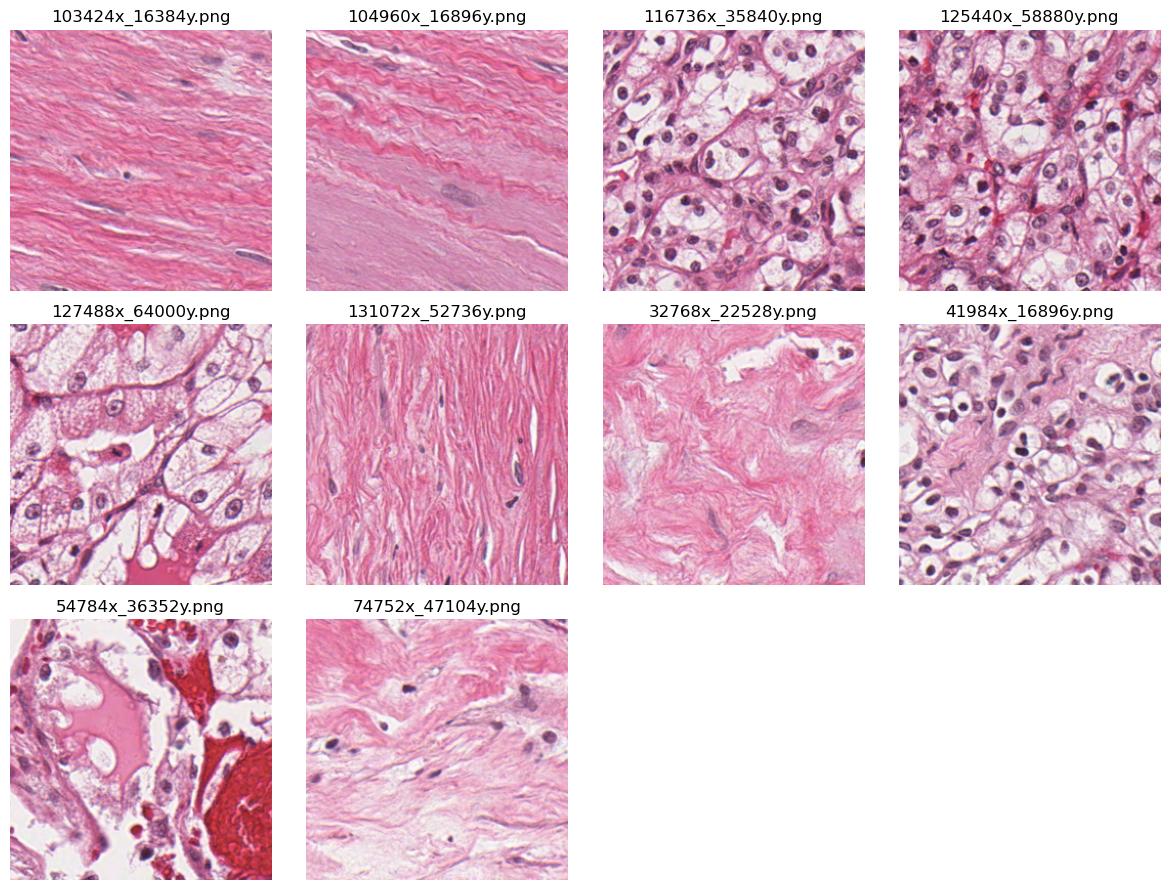

In [17]:
def show_outputs_for_slide(slide_id: str, out_dir: Path = OUT_DIR, n: int = 12):
    slide_dir = out_dir / slide_id
    csv_path = slide_dir / 'dataset.csv'

    if not csv_path.exists():
        print('Missing', csv_path)
        return

    df = pd.read_csv(csv_path)
    print('Rows:', len(df))
    display(df.head())

    imgs = sorted(slide_dir.glob('*.png'))[:n]
    if not imgs:
        print('No tiles found.')
        return

    cols = 4
    rows = int(np.ceil(len(imgs) / cols))
    plt.figure(figsize=(3 * cols, 3 * rows))
    for i, p in enumerate(imgs, 1):
        plt.subplot(rows, cols, i)
        plt.imshow(Image.open(p))
        plt.title(p.name)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Example:
first_slide = pd.read_csv(MANIFEST_CSV).iloc[1]['slide_id']
show_outputs_for_slide(first_slide)


### 13) Repo mapping notes

Mapped directly:
- `get_luminance`, `segment_foreground`
- `get_tile_descriptor`, `get_tile_id`, `save_image`, `get_tile_info`

Conceptually equivalent but streaming-safe:
- Instead of `LoadROId` + `tile_array_2d` on full ROI tensor, we do
  thumbnail foreground + coordinate filtering + per-tile streaming reads.

This keeps the same preprocessing intent with much lower peak RAM.


#### HPC tuning for streaming notebook (recommended for production)

This notebook is memory-safe & default on HPC.

- GPU: A30 (24 GB VRAM)
- CPU RAM: ~1000 GB
- CPU: 64 cores (2 sockets x 32 cores)

Guidance:
1. Preprocessing/tiling is CPU + storage I/O bound. GPU is mostly unused here.
2. Run slide-level parallelism with scheduler arrays or moderate local parallel workers.
3. Keep `target_mpp` physically meaningful (`0.25` ~= 40x, `0.5` ~= 20x).
4. Use A30 for embedding/model inference after tiles are generated.


#### Repo function mapping (streaming notebook)

Exact equivalents:
- `get_luminance` -> `get_luminance`
- `segment_foreground` -> `segment_foreground`
- `get_tile_descriptor` -> `get_tile_descriptor`
- `get_tile_id` -> `get_tile_id`
- `save_image` -> `save_image`
- `get_tile_info` -> `get_tile_info`

Streaming replacements (same intent, safer memory):
- Repo ROI tensor + `tile_array_2d` -> coordinate-first filtering + per-tile `read_region`
- Repo `process_slide` -> `process_slide_streaming`
